In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Colormap 에서 1차 성분을 클릭으로 추출한 결과(수작업)

data = pd.read_csv('City_Mode.csv', sep = ',')

In [3]:
data.tail()

,sec,spd,Unnamed: 2
945,448150,470,NaN
946,452125,340,NaN
947,459650,390,NaN
948,465300,445,NaN
949,470000,445,NaN


In [4]:
data['spd']

0      405
1      410
2      480
3      535
4      535
      ... 
945    470
946    340
947    390
948    445
949    445
Name: spd, Length: 950, dtype: int64

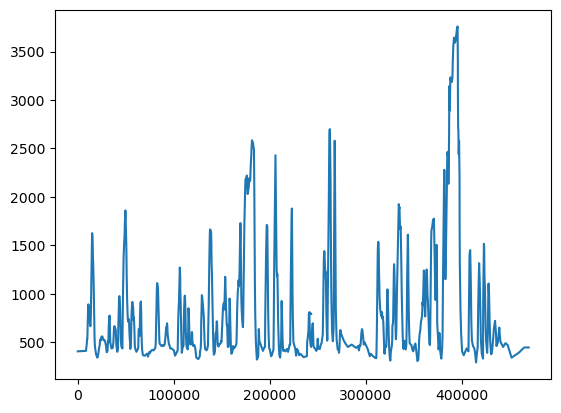

In [6]:
plt.plot(data.sec, data.spd)

In [7]:
data_city = pd.DataFrame(index=range(0, 469900), columns=['time', 'speed'])

In [8]:
data_city

,time,speed
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
469895,NaN,NaN
469896,NaN,NaN
469897,NaN,NaN
469898,NaN,NaN


In [9]:
'''

for i in range(0, len(data_city)):
    data_city.time[i] = i+100

'''

for i in range(0, len(data_city)):
    data_city.iat[i, 0] = i+100

In [10]:
data_city

,time,speed
0,100,NaN
1,101,NaN
2,102,NaN
3,103,NaN
4,104,NaN
...,...,...
469895,469995,NaN
469896,469996,NaN
469897,469997,NaN
469898,469998,NaN


In [ ]:

'''
for i in range(0, len(data_city)):
    for j in range(0, len(data)):
        if data_city.time[i] == data.sec[j]:
            data_city.speed[i] = data.spd[j]
            print("matched (i, j) =", i, j)
            break
'''
# 데이터프레임 인덱싱 방법 : iat 사용하면 시간 개선 (241126)
# 두 코드의 인덱싱 속도 비교 필요 + 하드웨어에 따른 차이(맥북, 인텔 비교)

for i in range(0, len(data_city)):
    for j in range(0, len(data)):
        if data_city.iat[i, 0] == data.iat[j, 0]:
            data_city.iat[i, 1] = data.iat[j, 1]
            print("matched (i, j) =", i, j)
            break



matched (i, j) = 0 0
matched (i, j) = 8525 1
matched (i, j) = 9350 2
matched (i, j) = 9800 3
matched (i, j) = 10000 4
matched (i, j) = 10175 5
matched (i, j) = 10350 6
matched (i, j) = 10625 7
matched (i, j) = 10800 8
matched (i, j) = 10950 9
matched (i, j) = 11050 10
matched (i, j) = 11275 11
matched (i, j) = 11600 12
matched (i, j) = 12125 13
matched (i, j) = 12650 14
matched (i, j) = 12925 15
matched (i, j) = 13125 16
matched (i, j) = 13300 17
matched (i, j) = 13650 18
matched (i, j) = 13925 19
matched (i, j) = 14125 20
matched (i, j) = 14550 21
matched (i, j) = 14750 22
matched (i, j) = 14875 23
matched (i, j) = 14950 24
matched (i, j) = 15075 25
matched (i, j) = 15325 26
matched (i, j) = 15575 27
matched (i, j) = 15850 28
matched (i, j) = 16050 29
matched (i, j) = 16150 30
matched (i, j) = 16250 31
matched (i, j) = 16500 32
matched (i, j) = 16750 33
matched (i, j) = 17100 34
matched (i, j) = 17475 35
matched (i, j) = 17725 36
matched (i, j) = 18075 37
matched (i, j) = 19075 38
mat

KeyboardInterrupt: 

In [ ]:
#### 앞에 확정된 i 값을 기억하여 -> 다음 루프에서는 그 뒤에 값만 검색하는 알고리즘으로 수정 -> 반복 속도 향상
# 처음부터 다시 시작할 필요가 없다.

# j가 950이 될 때까지 계속 실행
# 결측치 부분 확인 - 49만개 데이터 중 결측치는 아래 선형보간법으로 채우기

# data_city.time[100]

200

In [ ]:
data.tail()

,sec,spd,Unnamed: 2
945,448150,470,NaN
946,452125,340,NaN
947,459650,390,NaN
948,465300,445,NaN
949,470000,445,NaN


In [43]:
data_city

,time,speed
0,100,NaN
1,101,NaN
2,102,NaN
3,103,NaN
4,104,NaN
...,...,...
469895,NaN,NaN
469896,NaN,NaN
469897,NaN,NaN
469898,NaN,NaN


In [ ]:
# 불필요한 하부 데이터 영역 삭제

data_city.drop([465100,469899], axis=0, inplace=True)
data_city

In [ ]:
# 여러개의 결측치를 선형보간법으로 채우기

data_city['speed'] = data_city['speed'].interpolate(method = 'polynomial', order=2)